## Expressions

In [1]:
%list

registered line magics: 
	- printerPrefix
	- load
	- tableSchema
	- jars
	- cmd
	- listMagic, list
	- read
	- classDiagram
	- reload-class
	- javadoc-html
	- listLineMagic
	- where, which
	- classpath
	- listCellMagic
	- commonshellcmd
	- git-graph-mermaid
	- printWithName
	- addMavenDependencies, maven, addMavenDependency
	- classpath-snapshot
	- pom, loadFromPOM
	- write
	- addMavenRepo, mavenRepo
	- class-info
registered cell magics: 
	- javasrcList
	- compile
	- javasrcConstructorByName
	- javasrcFieldByName
	- write
	- timeit, timeIt, time
	- benchmark
	- plantUMLFile
	- plantUML
	- commonshell
	- javasrcInterfaceByName
	- javasrcMethodByAnnotationName
	- sqlAsTable
	- shell
	- classDiagram
	- javasrcClassByName
	- tableSchema
	- javasrcJavadoc
	- pom, loadFromPOM
	- mycompile
	- rdbmsSchema
	- javasrcMethodByName


In [2]:
"Hello world !";

"Helloworld!";: Hello world !

In [3]:
3+4*2

3+4*2: 11

## Methods and Classes in cells

In [4]:
// Basic method example: define a helper class with a static method and call it
class Helper {
  static int add(int a, int b) { return a + b; }
}
System.out.println(Helper.add(2, 3));

5


In [5]:
// Simple class example: define a Person class and instantiate it
class Person {
  String name;
  Person(String name) { this.name = name; }
  String greet() { return "Hello, I am " + name; }
}
Person p = new Person("Alice");
System.out.println(p.greet());

Hello, I am Alice


## External compilation

In [6]:
%maven org.projectlombok:lombok:1.18.42

In [7]:
%%compile --help

## %%compile - Compile Java source code and add to classpath

**Usage:** `%%compile [--verbose] [--debug] [--nowarn] fully.qualified.ClassName`

**Arguments:**
- `className` : Fully qualified class name (e.g., com.example.MyClass)

**Options:**
- `--verbose, -v` : Enable verbose compilation output
- `--debug, -d` : Include debug information in compiled classes
- `--nowarn, -w` : Suppress compiler warnings
- `--help, -h` : Show this help message

**Examples:**
```
%%compile com.example.Calculator
public class Calculator {
    public int add(int a, int b) { return a + b; }
}
```

```
%%compile --verbose --debug com.example.MyClass
public class MyClass {
    public void hello() { System.out.println("Hello!"); }
}
```

**Note:** Package declaration will be added automatically if not present.



In [8]:
%%compile --class=com.example.demo.Hello --output=out
package com.example.demo;
public class Hello {
  public static String greet() { return "Hello from compiled class"; }
}

After the `%%compile` cell finishes, the compiled classes are placed in the specified `out` directory and are added to the kernel classpath automatically by the magics (as exercised by the tests).

In [9]:
com.example.demo.Hello.greet();

com.example.demo.Hello.greet();: Hello from compiled class

In [10]:
%%compile --class=com.example.demo.LombokPerson --output=out --processor-path=/var/home/bruno/.m2/repository/org/projectlombok/lombok/1.18.42/lombok-1.18.42.jar --classpath=/var/home/bruno/.m2/repository/org/projectlombok/lombok/1.18.42/lombok-1.18.42.jar
package com.example.demo;
import lombok.Data;
import lombok.AllArgsConstructor;
@Data
@AllArgsConstructor
public class LombokPerson {
  private String name;
  private int age;
}

In [11]:
// Instantiate and use the compiled Lombok class
com.example.demo.LombokPerson lp = new com.example.demo.LombokPerson("Bob", 30);
System.out.println(lp.getName() + " age=" + lp.getAge());
System.out.println(lp);

Bob age=30


LombokPerson(name=Bob, age=30)


## Shell

In [12]:
%%shell --help

## %%shell - Execute shell commands

**Usage:** `%%shell [--shell=SHELL] [--timeout=SECONDS]`

**Options:**
- `--shell=SHELL` : Shell to use (default: zsh, or $SHELL environment variable)
- `--timeout=SECONDS` : Maximum execution time in seconds (default: 180)
- `--help, -h` : Show this help message

**Examples:**
```
%%shell
ls -la
```

```
%%shell --shell=bash
echo "Using bash"
```

```
%%shell --timeout=60
long-running-command
```



In [13]:
%%shell
# Run a simple shell command. The shared executor streams stdout/stderr and preserves environment variables across cells when appropriate.
echo $SHELL
echo "Hello from shell"
export MYVAR=42
echo $MYVAR

bash
Hello from shell
42


In [14]:
%%shell --shell=zsh
echo $SHELL
echo "Hello from zsh shell"


bash
Hello from zsh shell


## Databases

In [15]:
%maven --help

%maven - Add individual Maven coordinates to the classpath

Usage: %maven <groupId>:<artifactId>[:<extension>[:<classifier>]]:<version> [<coord> ...]

Examples:
  %maven org.h2:h2:2.4.240
  %maven com.google.guava:guava:32.1.2-jre org.apache.commons:commons-lang3:3.12.0

Options:
  --help, -h    Show this help message

Notes:
  Coordinates must follow Maven coordinate format. Multiple coordinates may be provided.


In [16]:
%maven com.h2database:h2:2.4.240

In [17]:
System.setProperty("jdbc.url", "jdbc:h2:mem:test;DB_CLOSE_DELAY=-1");
System.setProperty("jdbc.user", "sa");
System.setProperty("jdbc.password", "");

In [18]:
%%sqlAsTable --help

In [19]:
%%sqlAsTable
-- Example using a JDBC connection defined by system properties: jdbc.url, jdbc.user, jdbc.password
-- Creates multiple related tables and demonstrates inserts, relationships, and joins

-- -----------------------------
-- Customers table
-- -----------------------------
CREATE TABLE IF NOT EXISTS customers(
    id INT PRIMARY KEY,
    name VARCHAR(100) NOT NULL
);

MERGE INTO customers VALUES
  (1, 'Alice'),
  (2, 'Bob');

-- -----------------------------
-- Products catalog
-- -----------------------------
CREATE TABLE IF NOT EXISTS products(
    id INT PRIMARY KEY,
    name VARCHAR(100) NOT NULL,
    price DECIMAL(10,2) NOT NULL
);

MERGE INTO products VALUES
  (1, 'Widget', 9.99),
  (2, 'Gadget', 19.95),
  (3, 'Thingamajig', 4.50);

-- -----------------------------
-- Orders table
-- -----------------------------
CREATE TABLE IF NOT EXISTS orders(
    id INT PRIMARY KEY,
    customer_id INT NOT NULL,
    order_date DATE NOT NULL,
    FOREIGN KEY(customer_id) REFERENCES customers(id)
);

MERGE INTO orders VALUES
  (1, 1, DATE '2025-12-01'),
  (2, 2, DATE '2025-12-02');

-- -----------------------------
-- Order items table (line items)
-- -----------------------------
CREATE TABLE IF NOT EXISTS order_items(
    order_id INT NOT NULL,
    product_id INT NOT NULL,
    qty INT NOT NULL,
    PRIMARY KEY(order_id, product_id),
    FOREIGN KEY(order_id) REFERENCES orders(id),
    FOREIGN KEY(product_id) REFERENCES products(id)
);

MERGE INTO order_items(order_id, product_id, qty) KEY(order_id, product_id) VALUES
  (1, 1, 2),
  (1, 3, 1),
  (2, 2, 4);

-- -----------------------------
-- Verify table contents
-- -----------------------------
SELECT * FROM customers;
SELECT * FROM products;
SELECT * FROM orders;
SELECT * FROM order_items;

-- -----------------------------
-- Example join: calculate total per order
-- -----------------------------
SELECT
    o.id AS order_id,
    o.order_date,
    c.name AS customer,
    SUM(p.price * oi.qty) AS total
FROM orders o
JOIN customers c ON c.id = o.customer_id
JOIN order_items oi ON oi.order_id = o.id
JOIN products p ON p.id = oi.product_id
GROUP BY o.id, o.order_date, c.name
ORDER BY o.id;


Updated 0 rows

Updated 2 rows

Updated 0 rows

Updated 3 rows

Updated 0 rows

Updated 2 rows

Updated 0 rows

Updated 3 rows

ID,NAME
1,Alice
2,Bob


In [20]:
%%rdbmsSchema --help

## %%rdbmsSchema - Render DB schema as PlantUML

Usage: %%rdbmsSchema [--help] [<schema>] [SVG|PNG] [--show-source] [include=<regex>] [exclude=<regex>]

Provide table names in the cell body (one per line) to limit the diagram.


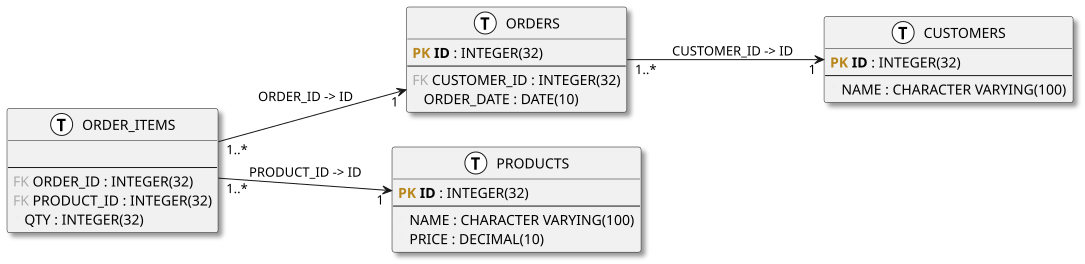

In [21]:
%%rdbmsSchema
-- Render the schema for a given JDBC connection as HTML/SVG (depends on implementation).
ORDERS
PRODUCTS
CUSTOMERS
ORDER_ITEMS

In [22]:
%tableSchema --help

%tableSchema - Show detailed table schema metadata

Usage: %tableSchema [schema.]table [--ddl] [--sample=N] [--compact] [--help]

Options:
  --ddl         Show a minimal CREATE TABLE DDL snippet
  --sample=N    Show up to N sample rows
  --compact     Show compact table summary in relational notation
  --help, -h    Show this help message


In [23]:
%tableSchema PRODUCTS --ddl --sample=3

| Column | Type | Nullable | Default | Remarks |
|---|---|:---:|---|---|
| ID (PK) (UNIQUE) | INTEGER(32) | NOT NULL |  |  |
| NAME | CHARACTER VARYING(100) | NOT NULL |  |  |
| PRICE | DECIMAL(10) | NOT NULL |  |  |

**Primary key**: ID

**Indexes**:
- PRIMARY_KEY_F (ID) UNIQUE

```
CREATE TABLE PRODUCTS (
    ID INTEGER(32) NOT NULL,
    NAME CHARACTER VARYING(100) NOT NULL,
    PRICE DECIMAL(10) NOT NULL,
    PRIMARY KEY (ID)
);
```


| ID | NAME | PRICE |
| --- | --- | --- |
| 1 | Widget | 9.99 |
| 2 | Gadget | 19.95 |
| 3 | Thingamajig | 4.50 |


In [24]:
%%tableSchema ORDERS --sample=3

| Column | Type | Nullable | Default | Remarks |
|---|---|:---:|---|---|
| ID (PK) (UNIQUE) | INTEGER(32) | NOT NULL |  |  |
| CUSTOMER_ID → CUSTOMERS(ID) | INTEGER(32) | NOT NULL |  |  |
| ORDER_DATE | DATE(10) | NOT NULL |  |  |

**Primary key**: ID

**Indexes**:
- CONSTRAINT_INDEX_8 (CUSTOMER_ID) 
- PRIMARY_KEY_8 (ID) UNIQUE

**Foreign keys**:
- CUSTOMER_ID → CUSTOMERS(ID)



| ID | CUSTOMER_ID | ORDER_DATE |
| --- | --- | --- |
| 1 | 1 | 2025-12-01 |
| 2 | 2 | 2025-12-02 |


In [25]:
%%tableSchema ORDER_ITEMS --sample=3

| Column | Type | Nullable | Default | Remarks |
|---|---|:---:|---|---|
| ORDER_ID (PK) → ORDERS(ID) | INTEGER(32) | NOT NULL |  |  |
| PRODUCT_ID (PK) → PRODUCTS(ID) | INTEGER(32) | NOT NULL |  |  |
| QTY | INTEGER(32) | NOT NULL |  |  |

**Primary key**: ORDER_ID, PRODUCT_ID

**Indexes**:
- CONSTRAINT_INDEX_2 (ORDER_ID) 
- PRIMARY_KEY_2 (ORDER_ID, PRODUCT_ID) UNIQUE
- CONSTRAINT_INDEX_2B (PRODUCT_ID) 

**Foreign keys**:
- ORDER_ID → ORDERS(ID)
- PRODUCT_ID → PRODUCTS(ID)



| ORDER_ID | PRODUCT_ID | QTY |
| --- | --- | --- |
| 1 | 1 | 2 |
| 1 | 3 | 1 |
| 2 | 2 | 4 |


In [26]:
%%tableSchema ORDER_ITEMS --compact

ORDER_ITEMS(ORDER_ID (PK) → ORDERS(ID), PRODUCT_ID (PK) → PRODUCTS(ID), QTY)



## Java source helper demos
These cells demonstrate the `%%javasrc*` magics for extracting classes, methods, constructors, fields, and Javadoc from source files. The demos use sample sources under `docs/sample_java` included in this repository.

In [27]:
%%javasrcClassByName --help

**Usage:** `%%javasrcClassByName <FullyQualifiedClassName>`

Extract entire class source by FQCN. Body may contain file path.

In [28]:
%%javasrcClassByName com.example.Greeter
../docs/sample_java/com/example/Greeter.java

```Java
public class Greeter {
    private final String name;

    public Greeter(String name) {
        this.name = name;
    }

    /**
     * Greets the person by name.
     * 
     * @return A greeting message.
     */
    public String greet() {
        return "Hello " + name;
    }
}
```

In [29]:
%%javasrcMethodByName --help

**Usage:** `%%javasrcMethodByName [options] <FullyQualifiedClassName|ClassName> [methodName|index]`

**Options:**
- `--src <dir>`: source root to resolve FQCN (e.g., `--src=sample_java`)
- `methodRegex=<regex>`: select methods whose name matches regex
- `selectIndex=<n>` or positional index: pick one when multiple matches
- `--raw` / `--fenced`: output format

**Examples:**
- `%%javasrcMethodByName methodRegex=summary --src=sample_java com.example.OrderExample`
- `%%javasrcMethodByName com.example.OrderExample myMethod`
- `%%javasrcMethodByName selectIndex=1 com.example.OrderExample myMethod`


In [30]:
%%javasrcMethodByName com.example.OrderExample summary
../docs/sample_java/com/example/OrderExample.java

```Java
/**
 * Returns a summary of the product.
 *
 * @param p The product to summarize.
 * @return A string summary of the product.
 */
public static String summary(Product p) {
    return p.id + ":" + p.name + ":" + p.price;
}
```

In [31]:
%%javasrcMethodByAnnotationName --help

**Usage:** `%%javasrcMethodByAnnotationName <FullyQualifiedClassName> <AnnotationName> [index]`

Extract methods annotated with a given annotation from source file (body should be path to file).

In [32]:
%%javasrcMethodByAnnotationName com.example.Product Deprecated
../docs/sample_java/com/example/Product.java

```Java
@Deprecated(since = 1)
public void oldMethod() {
    System.out.println("old ...");
}
```

In [33]:
%%javasrcConstructorByName --help

**Usage:** `%%javasrcConstructorByName <FullyQualifiedClassName>`

Show constructors for a class. Body may contain file path.

In [34]:
%%javasrcConstructorByName com.example.Product
../docs/sample_java/com/example/Product.java

```Java
0: Product(long, String)

public Product(long id, String name) {
    this(id, name, -1);
}

1: Product(long, String, double)

public Product(long id, String name, double price) {
    this.id = id;
    this.name = name;
    this.price = price;
}


```

In [35]:
%%javasrcFieldByName --help

**Usage:** `%%javasrcFieldByName <FullyQualifiedClassName> [filter] [--full=true]`

List or show fields for a class.

In [36]:
%%javasrcFieldByName com.example.Greeter
../docs/sample_java/com/example/Greeter.java

```Java
String name (modifiers: private  final )

private final String name;


```

In [37]:
%%javasrcJavadoc --help

**Usage:** `%%javasrcJavadoc <FullyQualifiedClassName> [memberName]`

Show javadoc for class or member.

In [38]:
%%javasrcJavadoc com.example.OrderExample
../docs/sample_java/com/example/OrderExample.java

OrderExample is a fake java class

- @see — Product

In [39]:
%%javasrcJavadoc com.example.OrderExample summary
../docs/sample_java/com/example/OrderExample.java

Returns a summary of the product.

- @param p — The product to summarize.
- @return — A string summary of the product.

## TimeIt demo
This cell demonstrates the `%%timeit` cell-magic (aliases `%%time`) to measure execution time. Use `iterations` and `warmup` to adjust sampling.

In [40]:
%%timeit --help

help: 
example: 

%%time epochs=3 loops=5
1 + 1


In [41]:
%%timeit iterations=5 warmup=1
// Simple workload: sum integers up to n and return the sum
int n = 100_000;
int s = 0;
for (int i = 0; i < n; i++) s += i;
s;

samples: [30675184, 31626125, 57277544, 56011050, 58324369]
min=30675184 median=56011050 avg=46782854,40 max=58324369 (nanoseconds)


## Benchmark: HashMap vs TreeMap
This cell runs the `%%benchmark` magic to compare `HashMap` and `TreeMap` performance. It performs a sweep over map sizes (`n`) and renders a chart. Adjust `start`/`end`/`step` to change the sweep range.

In [42]:
%%benchmark --help

## %%benchmark - Compare implementations performance

Usage: %%benchmark [--help] [--sweep var=<name> start=<n> end=<n> step=<n>] [--chart] [iterations=<n>] [warmup=<n>]\n
Provide one or more implementations separated by a line containing '---'.
Example:
%%benchmark iterations=5
code-for-impl-1
---
code-for-impl-2



In [43]:
// Helper: run a Supplier-driven test and return accumulated result
import java.util.function.Supplier;
// runSupplierTest calls the supplier 'iterations' times and accumulates its results
int runSupplierTest(Supplier<Integer> supplier, int iterations) {
  int acc = 0;
  for (int i = 0; i < iterations; i++) acc += supplier.get();
  return acc;
}

// Factory: build a Supplier that performs a mixed random read/write workload
// mapFactory: creates an empty Map<Integer,Integer>
// readRatio: fraction of operations that are reads (0.0-1.0)
// opsPerInvocation: number of random ops the supplier performs per get()
import java.util.Map;
import java.util.Random;
Supplier<Integer> makeMapRWTest(java.util.function.Supplier<Map<Integer,Integer>> mapFactory, double readRatio, int opsPerInvocation) {
  Map<Integer,Integer> map = mapFactory.get();
  Random initRnd = new Random(12345);
  // pre-populate map with a sparse keyspace
  for (int i = 0; i < n; i++) map.put(initRnd.nextInt(n * 10), i);
  Random localRnd = new Random(54321);
  return () -> {
    int localAcc = 0;
    for (int op = 0; op < opsPerInvocation; op++) {
      if (localRnd.nextDouble() < readRatio) {
        Integer v = map.get(localRnd.nextInt(n * 10));
        localAcc += (v != null) ? v : 0;
      } else {
        int key = localRnd.nextInt(n * 10);
        map.put(key, localRnd.nextInt());
      }
    }
    return localAcc;
  };
}

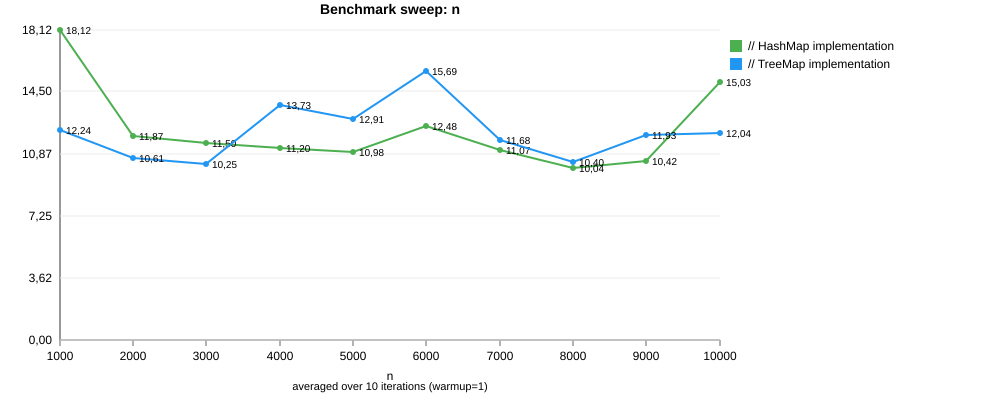

In [44]:
%%benchmark --sweep --chart var=n start=1000 end=10000 step=1000 iterations=10 warmup=1
// HashMap implementation
import java.util.HashMap;
java.util.function.Supplier<Integer> sanitySupplier = makeMapRWTest(() -> new java.util.HashMap<>(), 0.9, n);
---
// TreeMap implementation
import java.util.TreeMap;
java.util.function.Supplier<Integer> sanitySupplier = makeMapRWTest(() -> new java.util.TreeMap<>(), 0.9, n);

## Class diagrams

Examples showing the new `%classDiagram` and `%%classDiagram` magics.

In [45]:
%classDiagram --help

%classDiagram - Generate UML class diagrams using PlantUML

USAGE:
  %classDiagram <fully.qualified.ClassName> [options]
  %classDiagram --package=<pkg> [options]

TARGET SELECTION:
  <ClassName>            Generate diagram for a single class.
  --package=<pkg>        Scan a package and include multiple classes.

OUTPUT FORMAT (choose one):
  --svg                  Render diagram as SVG image (default).
  --png                  Render diagram as PNG image.
  --uml                  Output raw PlantUML text only (no rendering).

SCOPE / SIZE CONTROL:
  --max=<N>              Maximum classes when scanning a package (default 50).

VISIBILITY / DETAIL:
  --non-public           Include non-public fields, methods, constructors.

HIERARCHY / ANCESTORS:
  --ancestors            Include superclasses and interfaces.
  --depth=<N>            Ancestor depth when --ancestors is used (default 3).

TYPE FILTERS:
  --interfaces-only      Include only interfaces.
  --classes-only         Include only cl

In [46]:
%classDiagram com.example.demo.Hello

Classpath error: com.example.demo.Hello
No classes found.


In [47]:
%%compile --class=com.example.demo.C --output=out
package com.example.demo;
interface C {
    default int x() { return 42; }
}

In [48]:
%%compile --class=com.example.demo.A --output=out
package com.example.demo;
public class A implements C {
}

In [49]:
%%compile --class=com.example.demo.B --output=out
package com.example.demo;
public class B extends A {
}

In [50]:
%%classDiagram --package=com.example.demo --svg

No classes found.


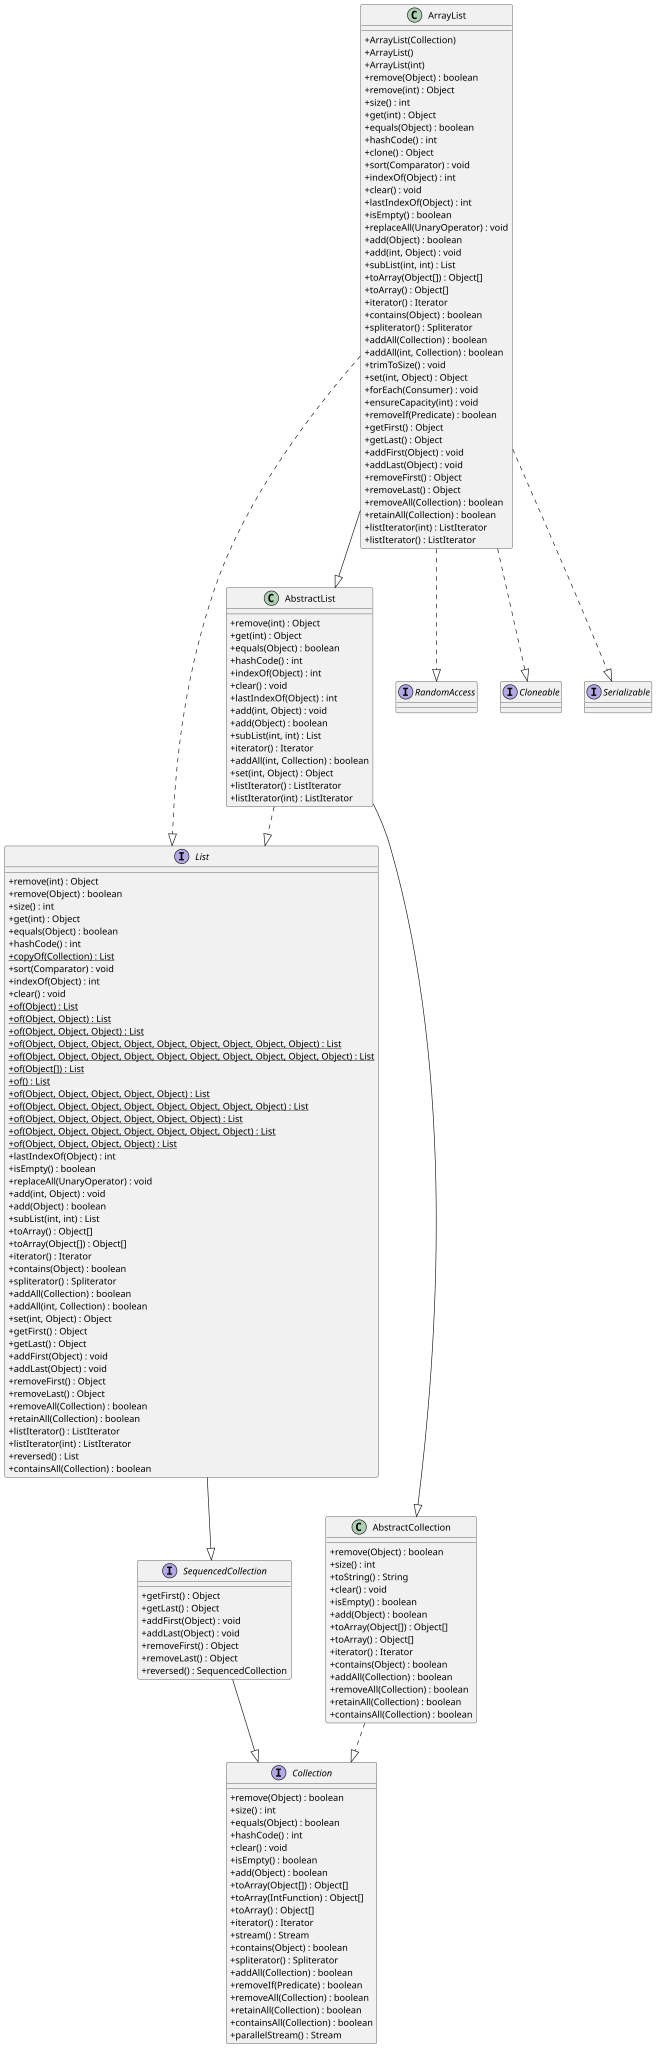

In [51]:
%%classDiagram java.util.ArrayList --svg --ancestors  --exclude-inherited

## Git graph (Mermaid)

Demonstrates the `%git-graph-mermaid` magic which emits Mermaid diagram source compatible with Quarto. Use `--format=gitGraph` for Mermaid's `gitGraph` syntax. Use `--render` to attempt local SVG rendering via `mmdc` (mermaid-cli), if installed.

In [52]:
%%shell
set -e
DEMO_REPO=/tmp/ijava-git-demo
rm -rf "$DEMO_REPO"
mkdir -p "$DEMO_REPO"
cd "$DEMO_REPO"
git init -b main .
echo 'hello file1' > file1.txt
git add file1.txt
git commit -m 'feat(demo): add file1'
echo 'another file' > file2.txt
git add file2.txt
git commit -m 'feat(demo): add file2'
echo "$DEMO_REPO"

Initialized empty Git repository in /tmp/ijava-git-demo/.git/


[main (root-commit) 354a0b6] feat(demo): add file1
 1 file changed, 1 insertion(+)
 create mode 100644 file1.txt
[main 0054e8b] feat(demo): add file2
 1 file changed, 1 insertion(+)
 create mode 100644 file2.txt
/tmp/ijava-git-demo


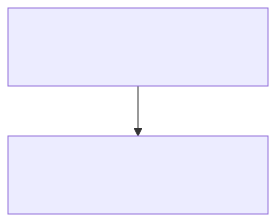

In [53]:
%git-graph-mermaid --repo=/tmp/ijava-git-demo --max=50 --format=gitGraph --render

In [54]:
%git-graph-mermaid --repo=/tmp/ijava-git-demo --max=50 --format=gitGraph

```{mermaid}\ngitGraph\n  branch main\n  checkout main\n  commit id: "0054e8b 0054e8b feat(demo): add file2"\n  commit id: "354a0b6 354a0b6 feat(demo): add file1"\n```\n

In [55]:
%%shell
rm -rf /tmp/ijava-git-demo || true
echo 'cleaned up /tmp/ijava-git-demo'

cleaned up /tmp/ijava-git-demo
